<div style="text-align:center; padding:4px 10px 28px 10px; margin:0 0 8px 0; border-bottom:1px solid #dbe6f0;">
<p style="margin:0 0 12px 0; font-family:'Segoe UI',Helvetica,Arial,sans-serif; font-size:26px; font-weight:800; color:#1B2A4A; letter-spacing:.3px;">Soluciones a los Retos Prácticos</p>
<p style="margin:0; font-family:'Segoe UI',Helvetica,Arial,sans-serif; font-size:14.5px; color:#4a5a72;">Estee documento preesenta la solución de los retos 6.1, 6.2 y 6.3 planteados en <code>00_red_neuronal_make_moons.ipynb</code>. La clase <code>NeuralNetwork</code> se reproduce aquí y se extiende según cada reto lo requiere.</p>
</div>

<div style="height:3px; border-radius:3px; background:linear-gradient(90deg,#1B2A4A,#2C5F8A,#E9A84C); margin:32px 0 6px 0;"></div>

## <span id="seccion-0" style="display:block; background:#2C5F8A; border-radius:10px; padding:14px 20px; margin:0;"><span style="display:inline-block; width:30px; height:30px; line-height:30px; text-align:center; background:#1B2A4A; color:#ffffff; border-radius:50%; font-family:'Segoe UI',Helvetica,Arial,sans-serif; font-weight:700; font-size:14px; vertical-align:middle;">0</span><span style="display:inline-block; margin-left:12px; color:#ffffff; font-family:'Segoe UI',Helvetica,Arial,sans-serif; font-size:18px; font-weight:700; letter-spacing:.2px; vertical-align:middle;">Configuración General</span></span>

Importamos las librerías comunes y fijamos la semilla aleatoria para reproducibilidad. Estas celdas son compartidas por los tres retos.

In [1]:
# Importar librerías
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons, make_blobs
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Configuración para reproducibilidad
np.random.seed(42)

Funciones de activación. A diferencia del notebook original (donde `relu_derivative` recibe la entrada pre-activación y `sigmoid_derivative` recibe la salida post-activación), aquí definimos **todas las derivadas de capas ocultas en función de la entrada pre-activación (`z`)**. Esto es necesario porque en el reto 6.1 intercambiaremos la activación de las capas ocultas (ReLU / Sigmoide / Tanh) y necesitamos una interfaz consistente para que el backpropagation sea correcto sin importar cuál se use.

In [2]:
def sigmoid(x):
    return 1 / (1 + np.exp(-np.clip(x, -500, 500)))  # np.clip para evitar overflow

def sigmoid_derivative(output):
    # Recibe la SALIDA de la sigmoide (uso exclusivo en la capa de salida, igual que el notebook original)
    return output * (1 - output)

def relu(x):
    return np.maximum(0, x)

HIDDEN_ACTIVATIONS = {
    'relu': relu,
    'sigmoid': sigmoid,
    'tanh': np.tanh,
}

HIDDEN_ACTIVATION_DERIVATIVES = {
    # Todas reciben z = entrada PRE-activación de la capa oculta
    'relu': lambda z: (z > 0).astype(float),
    'sigmoid': lambda z: sigmoid(z) * (1 - sigmoid(z)),
    'tanh': lambda z: 1 - np.tanh(z) ** 2,
}

Clase `NeuralNetwork` base: misma estructura que la del notebook original (arquitectura de 2 capas ocultas + optimizador Adam), con tres ajustes necesarios para que los experimentos de los retos funcionen correctamente:

1. **Activación configurable.** Se generaliza para aceptar la activación de las capas ocultas como parámetro (`hidden_activation`), necesario para el reto 6.1.
2. **Corrección de un bug de forma (shape) en el cálculo de la pérdida de monitoreo.** En `train()`, `y_batch` tiene forma `(batch,)` mientras que `predicted_output` tiene forma `(batch,1)`. Al llamar `binary_cross_entropy(y_batch, predicted_output)` sin remodelar `y_batch`, NumPy hace *broadcasting* de `(batch,)` contra `(batch,1)` y produce una matriz `(batch,batch)` en lugar de comparar cada predicción con su etiqueta correspondiente — esto corrompe silenciosamente el valor de pérdida que se imprime y que decide el *early stopping* (aunque, por suerte, **no** afecta a los gradientes reales, porque `backward()` sí remodela `y` correctamente). Es un bug ya presente en el notebook original: por eso su propia celda de entrenamiento (sección 4) reporta `Loss: 0.9365` en la época 10 y hace *early stopping* en la época 14, a pesar de que el modelo seguía aprendiendo razonablemente bien. Lo corregimos aquí remodelando `y_true` al inicio de `binary_cross_entropy`, para que las curvas de pérdida de los experimentos reflejen el comportamiento real del entrenamiento.
3. **Simplificación algebraica estable del gradiente de salida.** En `backward`, el gradiente de la capa de salida se calcula directamente como `predicted_output - y` en vez de `((y_pred - y)/(y_pred·(1-y_pred))) · (y_pred·(1-y_pred))`. Ambas expresiones son **algebraicamente idénticas** (los factores `y_pred·(1-y_pred)` se cancelan — la misma simplificación que se explica en detalle en el reto 6.3), pero la segunda forma puede sufrir cancelación numérica cuando las predicciones se saturan cerca de 0 o 1.

In [3]:
class NeuralNetwork:
    def __init__(self, input_size, hidden_size1, hidden_size2, output_size,
                 learning_rate=0.001, beta1=0.9, beta2=0.999, epsilon=1e-8,
                 hidden_activation='relu'):
        # Inicializa pesos y sesgos aleatoriamente
        self.weights_input_hidden1 = np.random.randn(input_size, hidden_size1) * 0.01
        self.bias_hidden1 = np.zeros((1, hidden_size1))
        self.weights_hidden1_hidden2 = np.random.randn(hidden_size1, hidden_size2) * 0.01
        self.bias_hidden2 = np.zeros((1, hidden_size2))
        self.weights_hidden2_output = np.random.randn(hidden_size2, output_size) * 0.01
        self.bias_output = np.zeros((1, output_size))

        self.learning_rate = learning_rate
        self.beta1 = beta1
        self.beta2 = beta2
        self.epsilon = epsilon

        self.hidden_activation = hidden_activation
        self._act = HIDDEN_ACTIVATIONS[hidden_activation]
        self._act_deriv = HIDDEN_ACTIVATION_DERIVATIVES[hidden_activation]

        # Parámetros para Adam (momentum y RMSprop)
        self.m_w1, self.v_w1 = np.zeros_like(self.weights_input_hidden1), np.zeros_like(self.weights_input_hidden1)
        self.m_b1, self.v_b1 = np.zeros_like(self.bias_hidden1), np.zeros_like(self.bias_hidden1)
        self.m_w2, self.v_w2 = np.zeros_like(self.weights_hidden1_hidden2), np.zeros_like(self.weights_hidden1_hidden2)
        self.m_b2, self.v_b2 = np.zeros_like(self.bias_hidden2), np.zeros_like(self.bias_hidden2)
        self.m_w3, self.v_w3 = np.zeros_like(self.weights_hidden2_output), np.zeros_like(self.weights_hidden2_output)
        self.m_b3, self.v_b3 = np.zeros_like(self.bias_output), np.zeros_like(self.bias_output)
        self.t = 0

    def forward(self, X):
        self.hidden_layer1_input = np.dot(X, self.weights_input_hidden1) + self.bias_hidden1
        self.hidden_layer1_output = self._act(self.hidden_layer1_input)

        self.hidden_layer2_input = np.dot(self.hidden_layer1_output, self.weights_hidden1_hidden2) + self.bias_hidden2
        self.hidden_layer2_output = self._act(self.hidden_layer2_input)

        self.output_layer_input = np.dot(self.hidden_layer2_output, self.weights_hidden2_output) + self.bias_output
        self.predicted_output = sigmoid(self.output_layer_input)
        return self.predicted_output

    def binary_cross_entropy(self, y_true, y_pred):
        # y_true llega con forma (batch,) y y_pred con forma (batch,1); sin
        # remodelar, numpy las hace broadcast a una matriz (batch,batch) en
        # lugar de comparar elemento a elemento, corrompiendo la pérdida.
        y_true = y_true.reshape(y_pred.shape)
        y_pred = np.clip(y_pred, 1e-10, 1 - 1e-10)
        return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

    def binary_cross_entropy_derivative(self, y_true, y_pred):
        y_pred = np.clip(y_pred, 1e-10, 1 - 1e-10)
        return (y_pred - y_true) / (y_pred * (1 - y_pred))

    def backward(self, X, y, predicted_output):
        y = y.reshape(-1, 1)

        # d_loss_d_output * sigmoid_derivative(predicted_output) se simplifica
        # algebraicamente a (predicted_output - y) -- ver interpretación del
        # reto 6.3. Usamos directamente la forma simplificada porque la versión
        # literal (dividir por p*(1-p) y luego volver a multiplicar por p*(1-p))
        # sufre cancelación numérica catastrófica cuando p se satura cerca de 0
        # o 1, lo que introduce inestabilidad en el entrenamiento.
        delta_output_layer = predicted_output - y

        error_hidden_layer2 = np.dot(delta_output_layer, self.weights_hidden2_output.T)
        delta_hidden_layer2 = error_hidden_layer2 * self._act_deriv(self.hidden_layer2_input)

        error_hidden_layer1 = np.dot(delta_hidden_layer2, self.weights_hidden1_hidden2.T)
        delta_hidden_layer1 = error_hidden_layer1 * self._act_deriv(self.hidden_layer1_input)

        grads_w3 = np.dot(self.hidden_layer2_output.T, delta_output_layer)
        grads_b3 = np.sum(delta_output_layer, axis=0, keepdims=True)

        grads_w2 = np.dot(self.hidden_layer1_output.T, delta_hidden_layer2)
        grads_b2 = np.sum(delta_hidden_layer2, axis=0, keepdims=True)

        grads_w1 = np.dot(X.T, delta_hidden_layer1)
        grads_b1 = np.sum(delta_hidden_layer1, axis=0, keepdims=True)

        return grads_w1, grads_b1, grads_w2, grads_b2, grads_w3, grads_b3

    def update_params_adam(self, grads_w1, grads_b1, grads_w2, grads_b2, grads_w3, grads_b3):
        self.t += 1

        self.m_w1 = self.beta1 * self.m_w1 + (1 - self.beta1) * grads_w1
        self.v_w1 = self.beta2 * self.v_w1 + (1 - self.beta2) * (grads_w1 ** 2)
        m_w1_corr = self.m_w1 / (1 - self.beta1 ** self.t)
        v_w1_corr = self.v_w1 / (1 - self.beta2 ** self.t)
        self.weights_input_hidden1 -= self.learning_rate * m_w1_corr / (np.sqrt(v_w1_corr) + self.epsilon)

        self.m_b1 = self.beta1 * self.m_b1 + (1 - self.beta1) * grads_b1
        self.v_b1 = self.beta2 * self.v_b1 + (1 - self.beta2) * (grads_b1 ** 2)
        m_b1_corr = self.m_b1 / (1 - self.beta1 ** self.t)
        v_b1_corr = self.v_b1 / (1 - self.beta2 ** self.t)
        self.bias_hidden1 -= self.learning_rate * m_b1_corr / (np.sqrt(v_b1_corr) + self.epsilon)

        self.m_w2 = self.beta1 * self.m_w2 + (1 - self.beta1) * grads_w2
        self.v_w2 = self.beta2 * self.v_w2 + (1 - self.beta2) * (grads_w2 ** 2)
        m_w2_corr = self.m_w2 / (1 - self.beta1 ** self.t)
        v_w2_corr = self.v_w2 / (1 - self.beta2 ** self.t)
        self.weights_hidden1_hidden2 -= self.learning_rate * m_w2_corr / (np.sqrt(v_w2_corr) + self.epsilon)

        self.m_b2 = self.beta1 * self.m_b2 + (1 - self.beta1) * grads_b2
        self.v_b2 = self.beta2 * self.v_b2 + (1 - self.beta2) * (grads_b2 ** 2)
        m_b2_corr = self.m_b2 / (1 - self.beta1 ** self.t)
        v_b2_corr = self.v_b2 / (1 - self.beta2 ** self.t)
        self.bias_hidden2 -= self.learning_rate * m_b2_corr / (np.sqrt(v_b2_corr) + self.epsilon)

        self.m_w3 = self.beta1 * self.m_w3 + (1 - self.beta1) * grads_w3
        self.v_w3 = self.beta2 * self.v_w3 + (1 - self.beta2) * (grads_w3 ** 2)
        m_w3_corr = self.m_w3 / (1 - self.beta1 ** self.t)
        v_w3_corr = self.v_w3 / (1 - self.beta2 ** self.t)
        self.weights_hidden2_output -= self.learning_rate * m_w3_corr / (np.sqrt(v_w3_corr) + self.epsilon)

        self.m_b3 = self.beta1 * self.m_b3 + (1 - self.beta1) * grads_b3
        self.v_b3 = self.beta2 * self.v_b3 + (1 - self.beta2) * (grads_b3 ** 2)
        m_b3_corr = self.m_b3 / (1 - self.beta1 ** self.t)
        v_b3_corr = self.v_b3 / (1 - self.beta2 ** self.t)
        self.bias_output -= self.learning_rate * m_b3_corr / (np.sqrt(v_b3_corr) + self.epsilon)

    def train(self, X_train, y_train, epochs, batch_size=32, early_stopping_patience=10, verbose=True):
        losses = []
        best_loss = float('inf')
        patience_counter = 0

        num_samples = X_train.shape[0]
        for epoch in range(epochs):
            permutation = np.random.permutation(num_samples)
            X_shuffled = X_train[permutation]
            y_shuffled = y_train[permutation]

            epoch_loss = 0
            n_batches = 0
            for i in range(0, num_samples, batch_size):
                X_batch = X_shuffled[i:i + batch_size]
                y_batch = y_shuffled[i:i + batch_size]

                predicted_output = self.forward(X_batch)
                grads = self.backward(X_batch, y_batch, predicted_output)
                self.update_params_adam(*grads)
                epoch_loss += self.binary_cross_entropy(y_batch, predicted_output)
                n_batches += 1

            avg_epoch_loss = epoch_loss / n_batches
            losses.append(avg_epoch_loss)

            if verbose and (epoch + 1) % 20 == 0:
                print(f'Epoch {epoch + 1}/{epochs}, Loss: {avg_epoch_loss:.4f}')

            if avg_epoch_loss < best_loss:
                best_loss = avg_epoch_loss
                patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter >= early_stopping_patience:
                    if verbose:
                        print(f'Early stopping at epoch {epoch + 1}')
                    break

        return losses

    def predict(self, X):
        return (self.forward(X) > 0.5).astype(int)


def plot_decision_boundary(model, X, y, title='Frontera de Decisión', ax=None):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    if ax is None:
        ax = plt.gca()
    ax.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.RdBu)
    ax.scatter(X[y == 0, 0], X[y == 0, 1], label='Clase 0', alpha=0.7, edgecolors='k', s=15)
    ax.scatter(X[y == 1, 0], X[y == 1, 1], label='Clase 1', alpha=0.7, edgecolors='k', s=15)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Característica 1')
    ax.set_ylabel('Característica 2')

<div style="height:3px; border-radius:3px; background:linear-gradient(90deg,#1B2A4A,#2C5F8A,#E9A84C); margin:32px 0 6px 0;"></div>

## <span id="seccion-6" style="display:block; background:#2C5F8A; border-radius:10px; padding:14px 20px; margin:0;"><span style="display:inline-block; width:30px; height:30px; line-height:30px; text-align:center; background:#1B2A4A; color:#ffffff; border-radius:50%; font-family:'Segoe UI',Helvetica,Arial,sans-serif; font-weight:700; font-size:14px; vertical-align:middle;">6</span><span style="display:inline-block; margin-left:12px; color:#ffffff; font-family:'Segoe UI',Helvetica,Arial,sans-serif; font-size:18px; font-weight:700; letter-spacing:.2px; vertical-align:middle;">Reto Práctico para Estudiantes: Soluciones</span></span>

A continuación se resuelven los tres retos propuestos en la sección 6 del notebook original: experimentación con hiperparámetros (6.1), regularización (6.2) y clasificación multiclase (6.3).

<div style="border-left:4px solid #2C5F8A; background:#EAF1F8; border-radius:0 8px 8px 0; padding:8px 16px; margin:22px 0 10px 0;">
<span style="font-family:ui-monospace,'Cascadia Code',Consolas,monospace; font-size:12px; font-weight:700; color:#2C5F8A; border:1px solid #2C5F8A; border-radius:4px; padding:1px 6px; margin-right:8px;">6.1</span>
<span style="font-family:'Segoe UI',Helvetica,Arial,sans-serif; font-size:15px; font-weight:700; color:#1B2A4A;">Experimentar con Hiperparámetros</span>
</div>

Generamos el conjunto de datos base (idéntico al notebook original: `make_moons(n_samples=1000, noise=0.15, random_state=42)`) que usaremos como referencia para los experimentos de arquitectura, tasa de aprendizaje y activación. El experimento de `noise` regenerará los datos con otros valores.

In [4]:
X_base, y_base = make_moons(n_samples=1000, noise=0.15, random_state=42)
scaler_base = StandardScaler()
X_base = scaler_base.fit_transform(X_base)
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(X_base, y_base, test_size=0.2, random_state=42)
print(f'Train: {X_train_b.shape}, Test: {X_test_b.shape}')

Train: (800, 2), Test: (200, 2)


**(a) Número de neuronas en las capas ocultas**

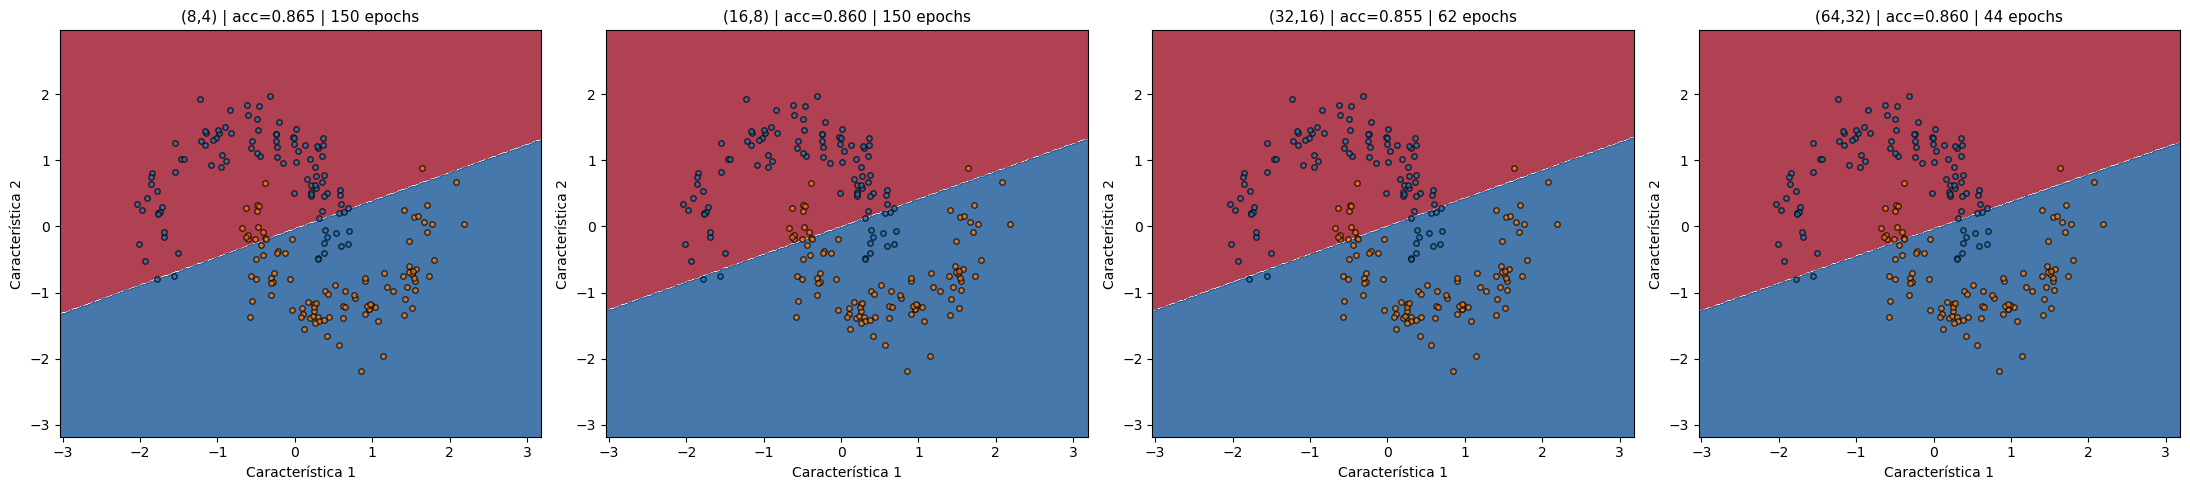

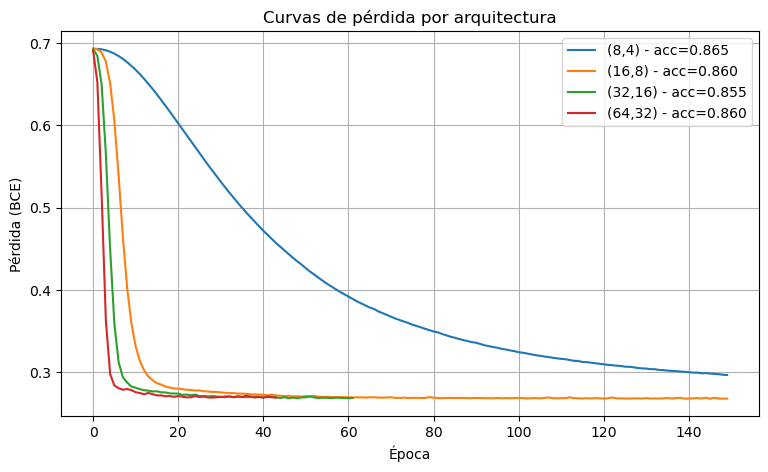

Arquitectura (8, 4): pérdida final=0.2969, épocas=150, accuracy test=0.8650
Arquitectura (16, 8): pérdida final=0.2682, épocas=150, accuracy test=0.8600
Arquitectura (32, 16): pérdida final=0.2690, épocas=62, accuracy test=0.8550
Arquitectura (64, 32): pérdida final=0.2696, épocas=44, accuracy test=0.8600


In [5]:
architectures = [(8, 4), (16, 8), (32, 16), (64, 32)]
arch_results = {}

fig, axes = plt.subplots(1, len(architectures), figsize=(22, 5))
for ax, (h1, h2) in zip(axes, architectures):
    np.random.seed(42)
    model = NeuralNetwork(2, h1, h2, 1, learning_rate=0.001)
    losses = model.train(X_train_b, y_train_b, epochs=150, batch_size=32, early_stopping_patience=15, verbose=False)
    acc = accuracy_score(y_test_b, model.predict(X_test_b))
    arch_results[(h1, h2)] = (losses, acc)
    plot_decision_boundary(model, X_test_b, y_test_b, title=f'({h1},{h2}) | acc={acc:.3f} | {len(losses)} epochs', ax=ax)
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 5))
for (h1, h2), (losses, acc) in arch_results.items():
    plt.plot(losses, label=f'({h1},{h2}) - acc={acc:.3f}')
plt.title('Curvas de pérdida por arquitectura')
plt.xlabel('Época'); plt.ylabel('Pérdida (BCE)'); plt.legend(); plt.grid(True)
plt.show()

for arch, (losses, acc) in arch_results.items():
    print(f'Arquitectura {arch}: pérdida final={losses[-1]:.4f}, épocas={len(losses)}, accuracy test={acc:.4f}')

**(b) Tasa de aprendizaje (`learning_rate`)**

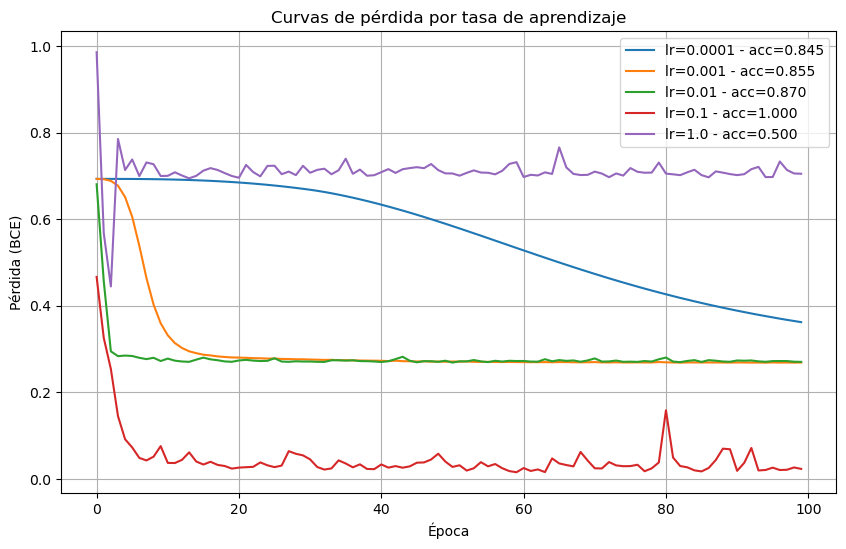

lr=0.0001: pérdida final=0.3622, pérdida máxima observada=0.6931, accuracy test=0.8450
lr=0.001: pérdida final=0.2690, pérdida máxima observada=0.6932, accuracy test=0.8550
lr=0.01: pérdida final=0.2704, pérdida máxima observada=0.6807, accuracy test=0.8700
lr=0.1: pérdida final=0.0231, pérdida máxima observada=0.4667, accuracy test=1.0000
lr=1.0: pérdida final=0.7051, pérdida máxima observada=0.9858, accuracy test=0.5000


In [6]:
learning_rates = [0.0001, 0.001, 0.01, 0.1, 1.0]
lr_results = {}

for lr in learning_rates:
    np.random.seed(42)
    model = NeuralNetwork(2, 16, 8, 1, learning_rate=lr)
    losses = model.train(X_train_b, y_train_b, epochs=100, batch_size=32, early_stopping_patience=100, verbose=False)
    acc = accuracy_score(y_test_b, model.predict(X_test_b))
    lr_results[lr] = (losses, acc, model)

plt.figure(figsize=(10, 6))
for lr, (losses, acc, _) in lr_results.items():
    plt.plot(losses, label=f'lr={lr} - acc={acc:.3f}')
plt.title('Curvas de pérdida por tasa de aprendizaje')
plt.xlabel('Época'); plt.ylabel('Pérdida (BCE)'); plt.legend(); plt.grid(True)
plt.show()

for lr, (losses, acc, _) in lr_results.items():
    print(f'lr={lr}: pérdida final={losses[-1]:.4f}, pérdida máxima observada={max(losses):.4f}, accuracy test={acc:.4f}')

Además de la curva de pérdida, conviene mirar la **frontera de decisión** que cada tasa de aprendizaje termina encontrando: la pérdida por sí sola no revela si el modelo realmente aprendió la forma no lineal del problema o se conformó con una solución mucho más simple.

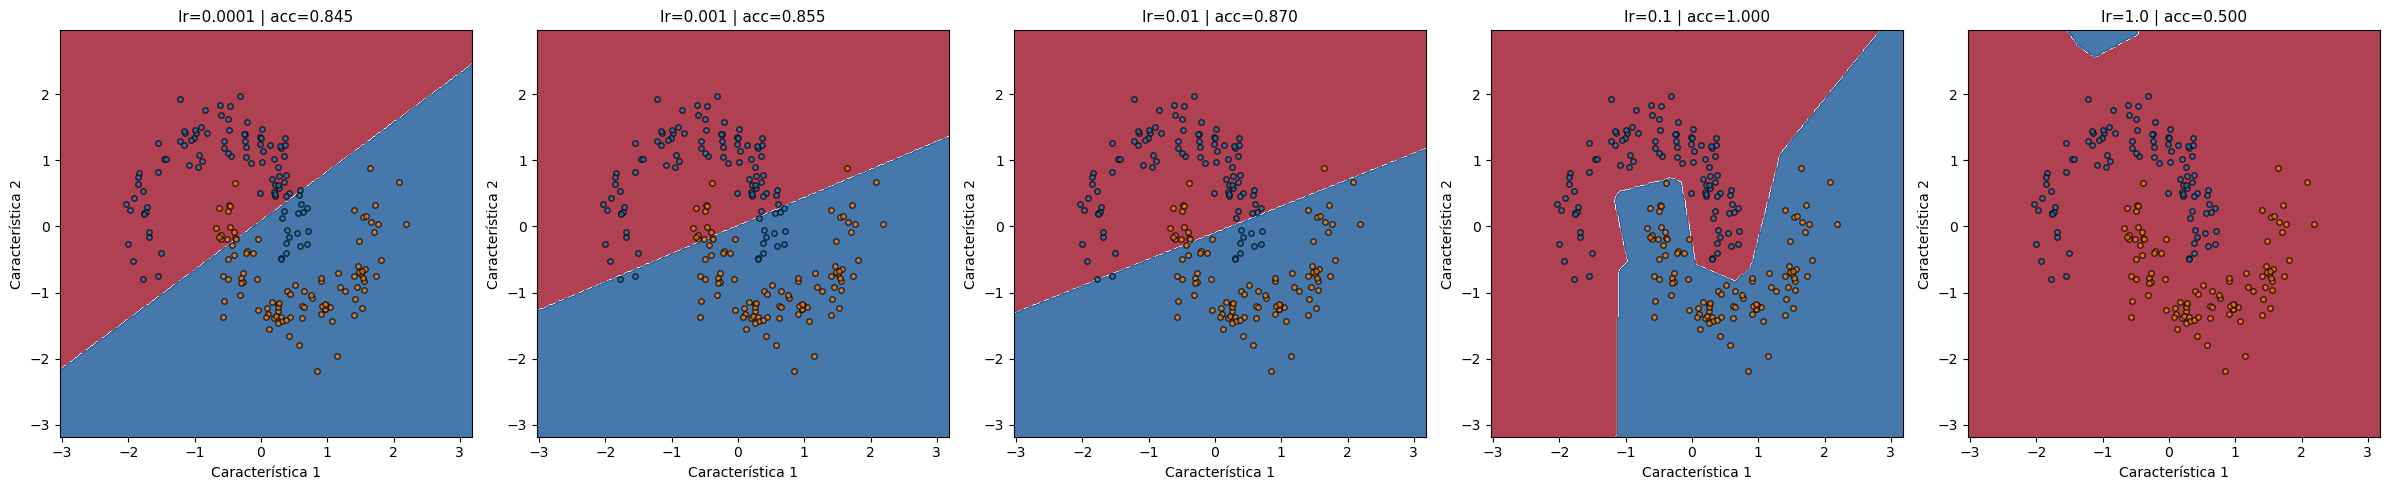

In [7]:
fig, axes = plt.subplots(1, len(learning_rates), figsize=(24, 5))
for ax, lr in zip(axes, learning_rates):
    _, acc, model_lr = lr_results[lr]
    plot_decision_boundary(model_lr, X_test_b, y_test_b, title=f'lr={lr} | acc={acc:.3f}', ax=ax)
plt.tight_layout()
plt.show()

**(c) Ruido en `make_moons` (`noise`)**

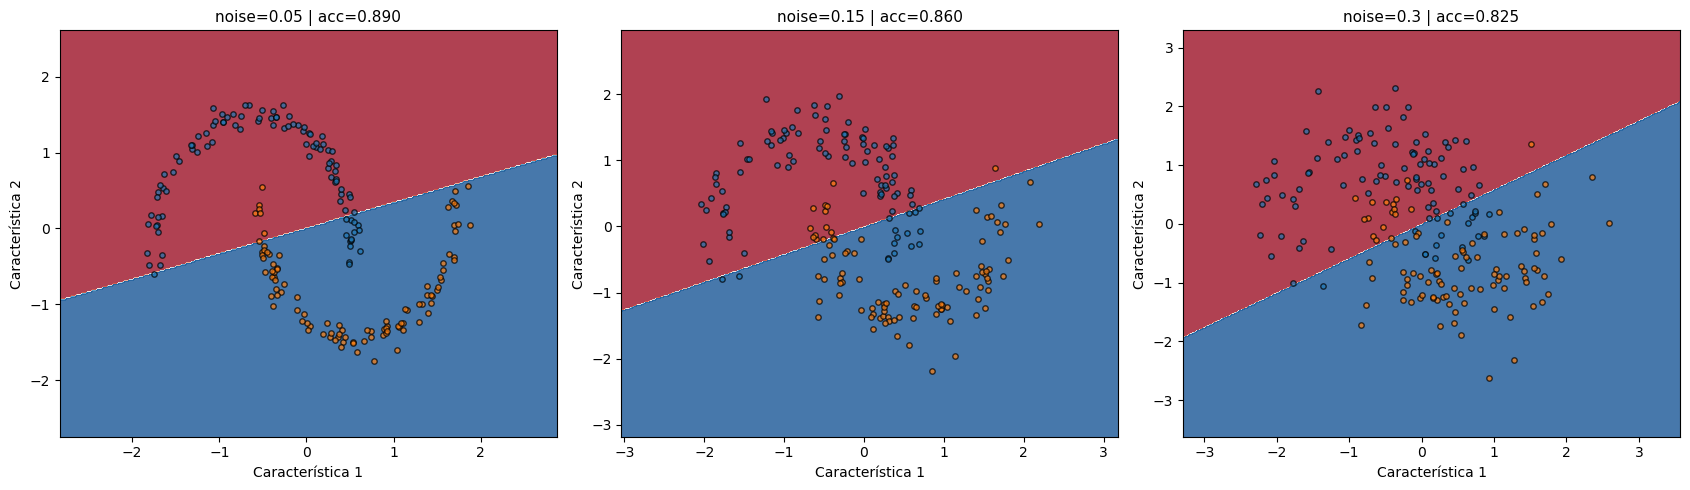

noise=0.05: accuracy test=0.8900
noise=0.15: accuracy test=0.8600
noise=0.3: accuracy test=0.8250


In [8]:
noise_levels = [0.05, 0.15, 0.3]
noise_results = {}

fig, axes = plt.subplots(1, len(noise_levels), figsize=(17, 5))
for ax, noise in zip(axes, noise_levels):
    Xn, yn = make_moons(n_samples=1000, noise=noise, random_state=42)
    Xn = StandardScaler().fit_transform(Xn)
    Xn_tr, Xn_te, yn_tr, yn_te = train_test_split(Xn, yn, test_size=0.2, random_state=42)

    np.random.seed(42)
    model = NeuralNetwork(2, 16, 8, 1, learning_rate=0.001)
    losses = model.train(Xn_tr, yn_tr, epochs=150, batch_size=32, early_stopping_patience=15, verbose=False)
    acc = accuracy_score(yn_te, model.predict(Xn_te))
    noise_results[noise] = acc
    plot_decision_boundary(model, Xn_te, yn_te, title=f'noise={noise} | acc={acc:.3f}', ax=ax)
plt.tight_layout()
plt.show()

for noise, acc in noise_results.items():
    print(f'noise={noise}: accuracy test={acc:.4f}')

**(d) Épocas de entrenamiento: sobreajuste vs. subajuste**

Para observar el punto en el que aparece el sobreajuste necesitamos seguir la pérdida de **entrenamiento y de prueba por separado**, época a época, sin que el early stopping detenga el proceso prematuramente.

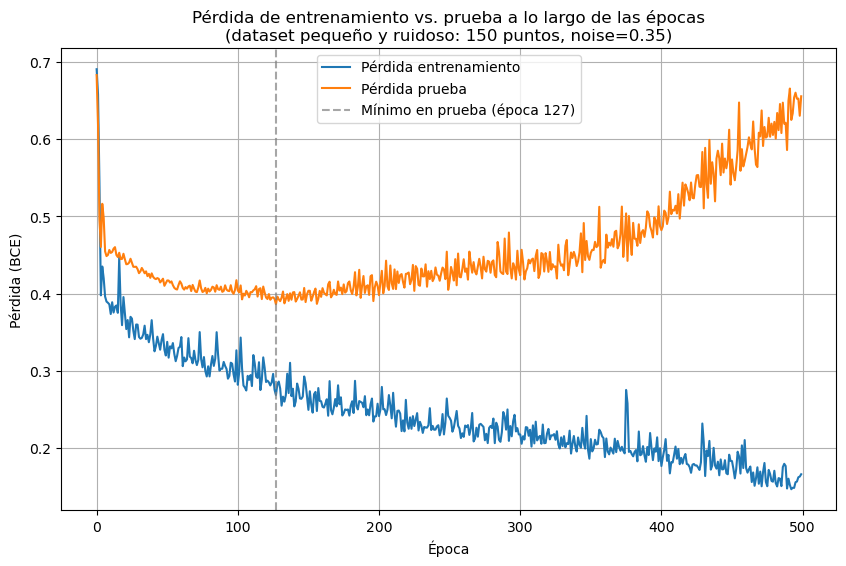

Mínima pérdida de prueba: 0.3864 en la época 127
Pérdida de entrenamiento en esa misma época: 0.2688
Pérdida de entrenamiento final (época 500): 0.1664
Pérdida de prueba final (época 500): 0.6555
Accuracy entrenamiento final: 0.9429 | Accuracy prueba final: 0.7778


In [9]:
def train_track_train_test(model, X_tr, y_tr, X_te, y_te, epochs, batch_size=32):
    train_losses, test_losses = [], []
    num_samples = X_tr.shape[0]
    for epoch in range(epochs):
        permutation = np.random.permutation(num_samples)
        X_shuffled, y_shuffled = X_tr[permutation], y_tr[permutation]
        epoch_loss, n_batches = 0, 0
        for i in range(0, num_samples, batch_size):
            X_batch = X_shuffled[i:i + batch_size]
            y_batch = y_shuffled[i:i + batch_size]
            pred = model.forward(X_batch)
            grads = model.backward(X_batch, y_batch, pred)
            model.update_params_adam(*grads)
            epoch_loss += model.binary_cross_entropy(y_batch, pred)
            n_batches += 1
        train_losses.append(epoch_loss / n_batches)
        test_pred = model.forward(X_te)
        test_losses.append(model.binary_cross_entropy(y_te, test_pred))
    return train_losses, test_losses

# Con la arquitectura y el dataset base (1000 puntos, noise=0.15) la red apenas
# sobreajusta: hay datos suficientes para el tamaño del modelo. Para que el
# sobreajuste sea visible en un número razonable de épocas usamos un dataset
# más pequeño y ruidoso (menos datos, más ambigüedad) con una red más grande.
X_of, y_of = make_moons(n_samples=150, noise=0.35, random_state=42)
X_of = StandardScaler().fit_transform(X_of)
X_train_of, X_test_of, y_train_of, y_test_of = train_test_split(X_of, y_of, test_size=0.3, random_state=42)

np.random.seed(42)
overfit_model = NeuralNetwork(2, 64, 64, 1, learning_rate=0.005)
train_losses, test_losses = train_track_train_test(overfit_model, X_train_of, y_train_of, X_test_of, y_test_of, epochs=500, batch_size=16)

plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Pérdida entrenamiento')
plt.plot(test_losses, label='Pérdida prueba')
best_epoch = int(np.argmin(test_losses))
plt.axvline(best_epoch, color='gray', linestyle='--', alpha=0.7, label=f'Mínimo en prueba (época {best_epoch})')
plt.title('Pérdida de entrenamiento vs. prueba a lo largo de las épocas\n(dataset pequeño y ruidoso: 150 puntos, noise=0.35)')
plt.xlabel('Época'); plt.ylabel('Pérdida (BCE)'); plt.legend(); plt.grid(True)
plt.show()

train_acc_of = accuracy_score(y_train_of, overfit_model.predict(X_train_of))
test_acc_of = accuracy_score(y_test_of, overfit_model.predict(X_test_of))
print(f'Mínima pérdida de prueba: {min(test_losses):.4f} en la época {best_epoch}')
print(f'Pérdida de entrenamiento en esa misma época: {train_losses[best_epoch]:.4f}')
print(f'Pérdida de entrenamiento final (época {len(train_losses)}): {train_losses[-1]:.4f}')
print(f'Pérdida de prueba final (época {len(test_losses)}): {test_losses[-1]:.4f}')
print(f'Accuracy entrenamiento final: {train_acc_of:.4f} | Accuracy prueba final: {test_acc_of:.4f}')

**(e) Función de activación en capas ocultas: ReLU vs. Sigmoide vs. Tanh**

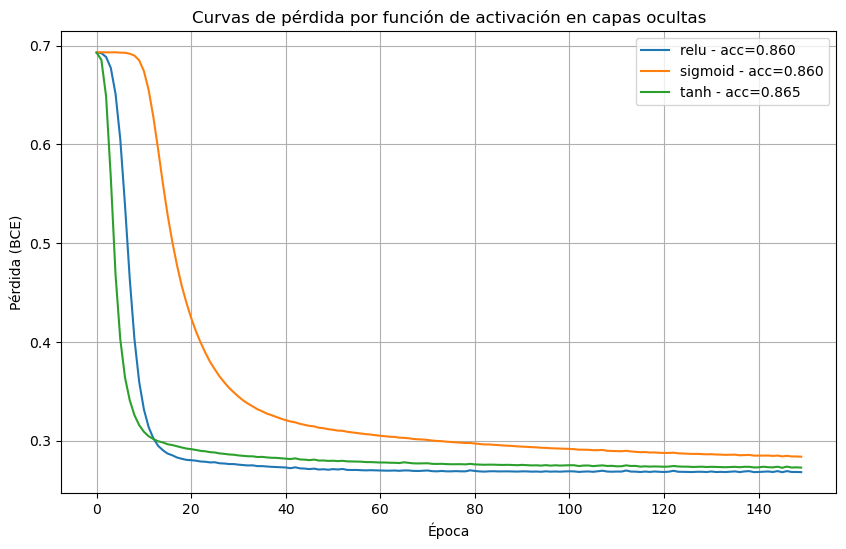

relu: pérdida final=0.2682, accuracy test=0.8600
sigmoid: pérdida final=0.2839, accuracy test=0.8600
tanh: pérdida final=0.2728, accuracy test=0.8650


In [10]:
activations = ['relu', 'sigmoid', 'tanh']
act_results = {}

for act in activations:
    np.random.seed(42)
    model = NeuralNetwork(2, 16, 8, 1, learning_rate=0.001, hidden_activation=act)
    losses = model.train(X_train_b, y_train_b, epochs=150, batch_size=32, early_stopping_patience=150, verbose=False)
    acc = accuracy_score(y_test_b, model.predict(X_test_b))
    act_results[act] = (losses, acc)

plt.figure(figsize=(10, 6))
for act, (losses, acc) in act_results.items():
    plt.plot(losses, label=f'{act} - acc={acc:.3f}')
plt.title('Curvas de pérdida por función de activación en capas ocultas')
plt.xlabel('Época'); plt.ylabel('Pérdida (BCE)'); plt.legend(); plt.grid(True)
plt.show()

for act, (losses, acc) in act_results.items():
    print(f'{act}: pérdida final={losses[-1]:.4f}, accuracy test={acc:.4f}')

### Interpretación de resultados — Reto 6.1

**Número de neuronas en las capas ocultas.** A `learning_rate=0.001` (el valor usado en este barrido) las cuatro arquitecturas terminan en un rango de pérdida y accuracy muy similar (pérdida final entre 0.268 y 0.297; accuracy entre 0.855 y 0.865) y, si se observan las fronteras de decisión, las cuatro son prácticamente **la misma recta diagonal** — ninguna llega a envolver la forma curva de las medias lunas, ni siquiera (64,32). La única diferencia visible entre arquitecturas es la velocidad: (8,4) consume las 150 épocas completas sin activar el early stopping, mientras que (16,8), (32,16) y (64,32) lo activan cada vez más rápido (150, 62 y 44 épocas). Esto podría hacer pensar que "más neuronas = mejor", pero el punto (b) revela la explicación real: a `lr=0.001` **ninguna** arquitectura logra escapar de una solución casi lineal dentro de un presupuesto razonable de épocas (de hecho, entrenar el mismo modelo (16,8) durante 1000 épocas con `lr=0.001` no mejora la pérdida más allá de ~0.27). El cuello de botella aquí no es la capacidad del modelo sino la velocidad de la optimización: con un learning rate más alto (`lr=0.05` o `lr=0.1`), incluso la red más pequeña, (8,4), alcanza accuracy ≈1.0 con una frontera curva. La lección importante es que **la capacidad de un modelo solo importa si el optimizador puede efectivamente alcanzar, en el presupuesto de entrenamiento disponible, una solución que la aproveche**; una red grande mal entrenada puede rendir igual (o peor, ver el reto 6.2) que una pequeña.

**Tasa de aprendizaje.** El barrido `[0.0001, 0.001, 0.01, 0.1, 1.0]` (arquitectura fija (16,8)) muestra el espectro completo del fenómeno, y aquí es donde se explica lo observado en (a). Con `lr=0.0001` la red apenas aprende en 100 épocas (pérdida final 0.362, accuracy 0.845): el paso es tan pequeño que desperdicia buena parte del presupuesto de épocas y la frontera de decisión resultante es prácticamente una línea recta poco ajustada. Con `lr=0.001` y `lr=0.01` el entrenamiento converge de forma estable a una pérdida baja (~0.27, accuracy 0.855–0.870), pero — como se ve en las fronteras de decisión — el modelo se conforma con una recta diagonal que separa razonablemente bien las clases sin llegar a curvarse alrededor de cada luna. Con `lr=0.1` ocurre un salto cualitativo: la pérdida cae a 0.023 y la accuracy llega a 1.0, y la frontera de decisión ahora sí es claramente no lineal, envolviendo la forma de cada media luna — el modelo finalmente "descubre" la solución curva que su capacidad (16,8) le permitía encontrar desde el principio. Esto es posible porque Adam **normaliza** cada paso por una estimación del segundo momento del gradiente, lo que lo hace bastante más tolerante a learning rates "grandes" que el descenso de gradiente clásico. Pero con `lr=1.0` el comportamiento colapsa: la pérdida oscila alrededor de 0.6–0.7 (prácticamente `ln 2 ≈ 0.693`, el valor de una red sin entrenar) y la accuracy cae a 0.50 (nivel de una moneda al aire); aquí el paso es tan grande que, incluso con la normalización de Adam, la actualización sobrepasa sistemáticamente la región del mínimo en cada iteración y el modelo nunca logra asentarse — la frontera de decisión resultante es errática y no separa las clases de forma consistente. En resumen: learning rate demasiado bajo → el modelo se estanca en una solución simple y subutiliza tanto las épocas como su propia capacidad; learning rate bien calibrado → el modelo explora y encuentra la solución no lineal que su arquitectura permite; learning rate demasiado alto → los pasos son tan grandes que el optimizador no logra converger, incluso con Adam de por medio.

**Ruido en `make_moons`.** Este experimento usa el mismo `lr=0.001` que (a), así que las tres fronteras de decisión vuelven a ser aproximadamente rectas (por la misma razón explicada en (b): a este learning rate el modelo no llega a explotar su capacidad no lineal en el presupuesto de épocas disponible) — lo interesante aquí no es la forma de la frontera sino cómo cambia la accuracy alcanzable con esa misma frontera al variar el ruido. La accuracy decrece de forma monótona: 0.890 (noise=0.05), 0.860 (noise=0.15) y 0.825 (noise=0.30). Con poco ruido las dos lunas están casi separadas y hasta una frontera simple las distingue razonablemente bien. Al aumentar el ruido, una fracción creciente de puntos cae en la zona de solapamiento entre clases — puntos que son ambiguos incluso para un clasificador óptimo, no solo para esta red en particular. Esto ilustra que más ruido no es (solo) un problema de optimización, sino de separabilidad de los datos: el techo de accuracy alcanzable baja porque sube el error de Bayes del problema, independientemente de qué tan bien entrenado esté el modelo.

**Épocas de entrenamiento — sobreajuste y subajuste.** Con el dataset base (1000 puntos, noise=0.15) la red apenas sobreajusta porque hay datos de sobra para su tamaño; por eso este experimento usa deliberadamente un dataset más pequeño y ruidoso (150 puntos, noise=0.35) con una red grande (64,64), condiciones mucho más propensas al sobreajuste. El resultado es un caso de libro: la pérdida de prueba alcanza su mínimo (0.386) en la época 127, con la pérdida de entrenamiento en ese mismo punto en 0.269 — brecha pequeña, el modelo generaliza razonablemente bien ahí. Si el entrenamiento continúa hasta la época 500, la pérdida de entrenamiento sigue bajando casi monótonamente hasta 0.166 (accuracy de entrenamiento 0.943), mientras que la pérdida de prueba **sube** hasta 0.655 (accuracy de prueba 0.778): la red está memorizando peculiaridades específicas del conjunto de entrenamiento (incluido el ruido) en vez de seguir aprendiendo el patrón general — la definición misma de sobreajuste. Si, en cambio, hubiéramos detenido el entrenamiento muy pronto (primeras 10-20 épocas), tanto la pérdida de entrenamiento como la de prueba habrían sido altas por igual: eso es subajuste, el modelo todavía no ha tenido oportunidad de aprender el patrón. El early stopping es precisamente el mecanismo que busca detener el entrenamiento cerca del mínimo de la curva de prueba, sin llegar hasta la zona de sobreajuste.

**Función de activación en capas ocultas.** Los tres modelos, dado un presupuesto amplio de 150 épocas con early stopping desactivado (`patience=150`), terminan en pérdidas finales parecidas (ReLU 0.268, Tanh 0.273, Sigmoide 0.284). Pero la **velocidad** de convergencia es marcadamente distinta: en las primeras 8 épocas, ReLU y Tanh ya bajan de 0.69 a ~0.40, mientras que Sigmoide se queda prácticamente estancada en 0.693 durante esas mismas 8 épocas y solo empieza a moverse con claridad después de la época 10. Esta arrancada lenta es la firma del **desvanecimiento del gradiente (vanishing gradient)**: la derivada de la sigmoide (`s·(1-s)`) tiene un valor máximo de 0.25 (en z=0) y se acerca rápidamente a 0 en sus extremos; al encadenar esta derivada a través de dos capas ocultas durante la retropropagación, el gradiente que llega a la primera capa se reduce multiplicativamente, haciendo que sus pesos se actualicen muy lentamente al principio del entrenamiento (cuando las activaciones están cerca del régimen saturado de la sigmoide, en torno a 0.5). ReLU y Tanh no sufren esa atenuación tan severa en este régimen inicial (ReLU tiene derivada constante 1 para entradas positivas; Tanh tiene derivada máxima 1, cuatro veces mayor que la de la sigmoide), por lo que aprenden más rápido desde el principio. Con suficientes épocas, la sigmoide termina alcanzando un resultado similar — pero en un presupuesto de épocas más ajustado (como el `epochs=100` usado en el experimento de learning rate), esa lentitud inicial sí se traduciría en una desventaja real.

<div style="border-left:4px solid #E9A84C; background:#FBF0DC; border-radius:0 8px 8px 0; padding:8px 16px; margin:26px 0 10px 0;">
<span style="font-family:'Segoe UI',Helvetica,Arial,sans-serif; font-size:15px; font-weight:700; color:#8a5a12;">&#128221; Evaluación de comprensión</span>
</div>

**Pregunta 1.** Al entrenar la red con `learning_rate=1.0` en lugar de `0.001`, la pérdida deja de decrecer y en su lugar oscila alrededor de ~0.6–0.7 (prácticamente el valor de una red sin entrenar, `ln 2 ≈ 0.693`), con la accuracy estancada en 0.50 (nivel de una moneda al aire). ¿Cuál es la explicación más precisa de este fenómeno?

- **A)** El optimizador Adam solo funciona correctamente con learning rates menores a 0.01; con valores mayores simplemente deja de aplicar las actualizaciones.
  *Incorrecta.* Adam sí aplica las actualizaciones sin importar el valor del learning rate (es solo un factor multiplicativo en la regla de actualización); no existe tal límite duro de funcionamiento. El problema no es que Adam "se apague", sino la magnitud de los pasos que produce.
- **B)** Los pasos de actualización de los pesos son demasiado grandes en relación con la curvatura de la función de pérdida, por lo que en cada actualización los pesos sobrepasan repetidamente la región del mínimo en lugar de acercarse gradualmente a él.
  *Correcta.* El learning rate escala el tamaño del paso de descenso de gradiente. Si es demasiado grande, el paso puede "saltar" más allá del mínimo local en cada iteración, y la siguiente actualización vuelve a saltar en la dirección opuesta: el resultado es oscilación o divergencia en vez de convergencia suave.
- **C)** Un learning rate alto hace que la red memorice los datos de entrenamiento inmediatamente, por lo que la oscilación observada es en realidad sobreajuste (overfitting) manifestándose desde las primeras épocas.
  *Incorrecta.* El sobreajuste se manifiesta como una brecha entre la pérdida de entrenamiento y la de prueba (entrenamiento bajo, prueba alta), no como oscilación de la propia pérdida de entrenamiento. Aquí el problema es de optimización (inestabilidad numérica de los pasos), no de generalización.
- **D)** Un learning rate alto reduce artificialmente la capacidad del modelo, forzando los pesos hacia valores cercanos a cero y produciendo predicciones casi aleatorias.
  *Incorrecta.* El learning rate no cambia la capacidad (arquitectura) del modelo ni fuerza los pesos a cero; de hecho, pasos grandes suelen producir pesos con magnitudes más erráticas y grandes, no más pequeñas.

---

**Pregunta 2.** Al reemplazar ReLU por Sigmoide como activación de las capas ocultas (manteniendo la misma arquitectura, learning rate y número de épocas), la pérdida se mantiene prácticamente estancada cerca de `ln 2 ≈ 0.693` durante las primeras épocas, y solo después empieza a descender con claridad — mientras que con ReLU o Tanh la pérdida ya baja notablemente desde las primeras iteraciones. ¿Cuál es la causa más precisa de este arranque lento?

- **A)** La derivada de la sigmoide tiene un valor máximo de 0.25 y se acerca a 0 en sus extremos; al encadenar esta derivada a través de las dos capas ocultas durante la retropropagación, el gradiente que llega a las capas más cercanas a la entrada se reduce multiplicativamente, ralentizando su actualización (vanishing gradient).
  *Correcta.* Es exactamente el fenómeno de desvanecimiento del gradiente: derivadas pequeñas (≤0.25) multiplicadas a través de varias capas producen gradientes cada vez más pequeños en las capas iniciales, haciendo que sus pesos apenas cambien.
- **B)** La sigmoide produce salidas negativas en algunas neuronas, lo cual es incompatible con el optimizador Adam y hace que las actualizaciones se cancelen entre sí.
  *Incorrecta.* La sigmoide produce salidas en el rango (0, 1), siempre positivas, nunca negativas. Adam no tiene ninguna restricción sobre el signo de las activaciones de las capas ocultas.
- **C)** La sigmoide no es diferenciable en todo su dominio, por lo que en ciertos puntos el backpropagation no puede calcular el gradiente y simplemente lo omite, ralentizando el aprendizaje.
  *Incorrecta.* La sigmoide es una función suave y diferenciable en todo su dominio (a diferencia de ReLU, que técnicamente no es diferenciable en z=0). No hay puntos donde el gradiente no pueda calcularse.
- **D)** La sigmoide introduce más parámetros entrenables por neurona que ReLU, lo que incrementa el costo computacional y hace que se necesiten más épocas para converger.
  *Incorrecta.* Ninguna de las dos funciones de activación añade parámetros entrenables: ambas son funciones fijas aplicadas elemento a elemento sobre la salida lineal de la capa. El número de pesos de la red es idéntico en ambos casos.

<div style="border-left:4px solid #2C5F8A; background:#EAF1F8; border-radius:0 8px 8px 0; padding:8px 16px; margin:22px 0 10px 0;">
<span style="font-family:ui-monospace,'Cascadia Code',Consolas,monospace; font-size:12px; font-weight:700; color:#2C5F8A; border:1px solid #2C5F8A; border-radius:4px; padding:1px 6px; margin-right:8px;">6.2</span>
<span style="font-family:'Segoe UI',Helvetica,Arial,sans-serif; font-size:15px; font-weight:700; color:#1B2A4A;">Implementar Regularización (L2 + Dropout)</span>
</div>

Extendemos la clase `NeuralNetwork` mediante herencia para añadir dos técnicas de regularización:

- **L2 (weight decay):** se añade `(λ/2N)·Σ‖W‖²` a la función de pérdida (para fines de monitoreo) y `λ·W` al gradiente de cada matriz de pesos antes de actualizar con Adam.
- **Dropout:** en cada forward pass de entrenamiento se genera una máscara binaria aleatoria (escalada por `1/(1-p)`, *inverted dropout*) que apaga una fracción `p` de las neuronas de cada capa oculta; en evaluación (`training=False`) no se aplica ninguna máscara.

Para que el efecto de la regularización sea visible, entrenamos con un **escenario propenso al sobreajuste**: una red relativamente grande (64,64), un conjunto de datos pequeño y ruidoso, y muchas épocas sin early stopping agresivo.

In [11]:
class NeuralNetworkRegularized(NeuralNetwork):
    def __init__(self, *args, l2_lambda=0.0, dropout_rate=0.0, **kwargs):
        super().__init__(*args, **kwargs)
        self.l2_lambda = l2_lambda
        self.dropout_rate = dropout_rate

    def forward(self, X, training=True):
        self.hidden_layer1_input = np.dot(X, self.weights_input_hidden1) + self.bias_hidden1
        a1 = self._act(self.hidden_layer1_input)
        if training and self.dropout_rate > 0:
            self.dropout_mask1 = (np.random.rand(*a1.shape) > self.dropout_rate) / (1 - self.dropout_rate)
        else:
            self.dropout_mask1 = np.ones_like(a1)
        self.hidden_layer1_output = a1 * self.dropout_mask1

        self.hidden_layer2_input = np.dot(self.hidden_layer1_output, self.weights_hidden1_hidden2) + self.bias_hidden2
        a2 = self._act(self.hidden_layer2_input)
        if training and self.dropout_rate > 0:
            self.dropout_mask2 = (np.random.rand(*a2.shape) > self.dropout_rate) / (1 - self.dropout_rate)
        else:
            self.dropout_mask2 = np.ones_like(a2)
        self.hidden_layer2_output = a2 * self.dropout_mask2

        self.output_layer_input = np.dot(self.hidden_layer2_output, self.weights_hidden2_output) + self.bias_output
        self.predicted_output = sigmoid(self.output_layer_input)
        return self.predicted_output

    def binary_cross_entropy(self, y_true, y_pred):
        base_loss = super().binary_cross_entropy(y_true, y_pred)
        if self.l2_lambda > 0:
            n = y_true.shape[0]
            l2_term = (self.l2_lambda / (2 * n)) * (
                np.sum(self.weights_input_hidden1 ** 2) +
                np.sum(self.weights_hidden1_hidden2 ** 2) +
                np.sum(self.weights_hidden2_output ** 2)
            )
            return base_loss + l2_term
        return base_loss

    def backward(self, X, y, predicted_output):
        y = y.reshape(-1, 1)
        # Forma simplificada y numéricamente estable (ver nota en NeuralNetwork.backward)
        delta_output_layer = predicted_output - y

        error_hidden_layer2 = np.dot(delta_output_layer, self.weights_hidden2_output.T)
        delta_hidden_layer2 = error_hidden_layer2 * self._act_deriv(self.hidden_layer2_input) * self.dropout_mask2

        error_hidden_layer1 = np.dot(delta_hidden_layer2, self.weights_hidden1_hidden2.T)
        delta_hidden_layer1 = error_hidden_layer1 * self._act_deriv(self.hidden_layer1_input) * self.dropout_mask1

        grads_w3 = np.dot(self.hidden_layer2_output.T, delta_output_layer)
        grads_b3 = np.sum(delta_output_layer, axis=0, keepdims=True)
        grads_w2 = np.dot(self.hidden_layer1_output.T, delta_hidden_layer2)
        grads_b2 = np.sum(delta_hidden_layer2, axis=0, keepdims=True)
        grads_w1 = np.dot(X.T, delta_hidden_layer1)
        grads_b1 = np.sum(delta_hidden_layer1, axis=0, keepdims=True)

        if self.l2_lambda > 0:
            grads_w3 = grads_w3 + self.l2_lambda * self.weights_hidden2_output
            grads_w2 = grads_w2 + self.l2_lambda * self.weights_hidden1_hidden2
            grads_w1 = grads_w1 + self.l2_lambda * self.weights_input_hidden1

        return grads_w1, grads_b1, grads_w2, grads_b2, grads_w3, grads_b3

    def predict(self, X):
        return (self.forward(X, training=False) > 0.5).astype(int)

    def train_with_validation(self, X_train, y_train, X_val, y_val, epochs, batch_size=32):
        train_losses, val_losses = [], []
        num_samples = X_train.shape[0]
        for epoch in range(epochs):
            permutation = np.random.permutation(num_samples)
            X_shuffled, y_shuffled = X_train[permutation], y_train[permutation]
            epoch_loss, n_batches = 0, 0
            for i in range(0, num_samples, batch_size):
                X_batch = X_shuffled[i:i + batch_size]
                y_batch = y_shuffled[i:i + batch_size]
                pred = self.forward(X_batch, training=True)
                grads = self.backward(X_batch, y_batch, pred)
                self.update_params_adam(*grads)
                epoch_loss += self.binary_cross_entropy(y_batch, pred)
                n_batches += 1
            train_losses.append(epoch_loss / n_batches)
            val_pred = self.forward(X_val, training=False)
            val_losses.append(self.binary_cross_entropy(y_val, val_pred))
        return train_losses, val_losses

Dataset pequeño y ruidoso (propenso a sobreajuste) y red grande (64,64):

Train: (105, 2), Test: (45, 2)


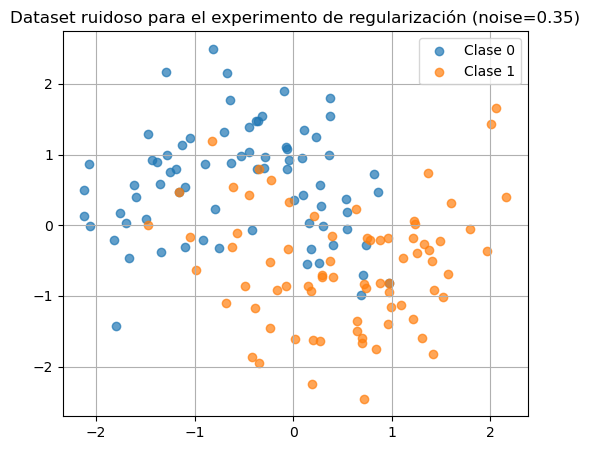

In [12]:
X_reg, y_reg = make_moons(n_samples=150, noise=0.35, random_state=42)
X_reg = StandardScaler().fit_transform(X_reg)
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg, y_reg, test_size=0.3, random_state=42)
print(f'Train: {X_train_r.shape}, Test: {X_test_r.shape}')

plt.figure(figsize=(6, 5))
plt.scatter(X_reg[y_reg == 0, 0], X_reg[y_reg == 0, 1], label='Clase 0', alpha=0.7)
plt.scatter(X_reg[y_reg == 1, 0], X_reg[y_reg == 1, 1], label='Clase 1', alpha=0.7)
plt.title('Dataset ruidoso para el experimento de regularización (noise=0.35)')
plt.legend(); plt.grid(True)
plt.show()

In [13]:
configs = {
    'Sin regularización': dict(l2_lambda=0.0, dropout_rate=0.0),
    'Solo L2': dict(l2_lambda=0.1, dropout_rate=0.0),
    'Solo Dropout': dict(l2_lambda=0.0, dropout_rate=0.5),
    'L2 + Dropout': dict(l2_lambda=0.1, dropout_rate=0.5),
}

reg_results = {}
for name, cfg in configs.items():
    np.random.seed(42)
    model = NeuralNetworkRegularized(2, 64, 64, 1, learning_rate=0.005, **cfg)
    train_losses, val_losses = model.train_with_validation(X_train_r, y_train_r, X_test_r, y_test_r, epochs=500, batch_size=16)
    acc = accuracy_score(y_test_r, model.predict(X_test_r))
    train_acc = accuracy_score(y_train_r, model.predict(X_train_r))
    reg_results[name] = dict(model=model, train_losses=train_losses, val_losses=val_losses,
                              test_acc=acc, train_acc=train_acc)
    print(f'{name:20s} | train_acc={train_acc:.4f} | test_acc={acc:.4f} | '
          f'gap_loss(final)={val_losses[-1]-train_losses[-1]:+.4f}')

Sin regularización   | train_acc=0.9429 | test_acc=0.7778 | gap_loss(final)=+0.4891


Solo L2              | train_acc=0.8286 | test_acc=0.8000 | gap_loss(final)=+0.0494


Solo Dropout         | train_acc=0.9238 | test_acc=0.7778 | gap_loss(final)=+0.2607


L2 + Dropout         | train_acc=0.8381 | test_acc=0.8222 | gap_loss(final)=+0.0282


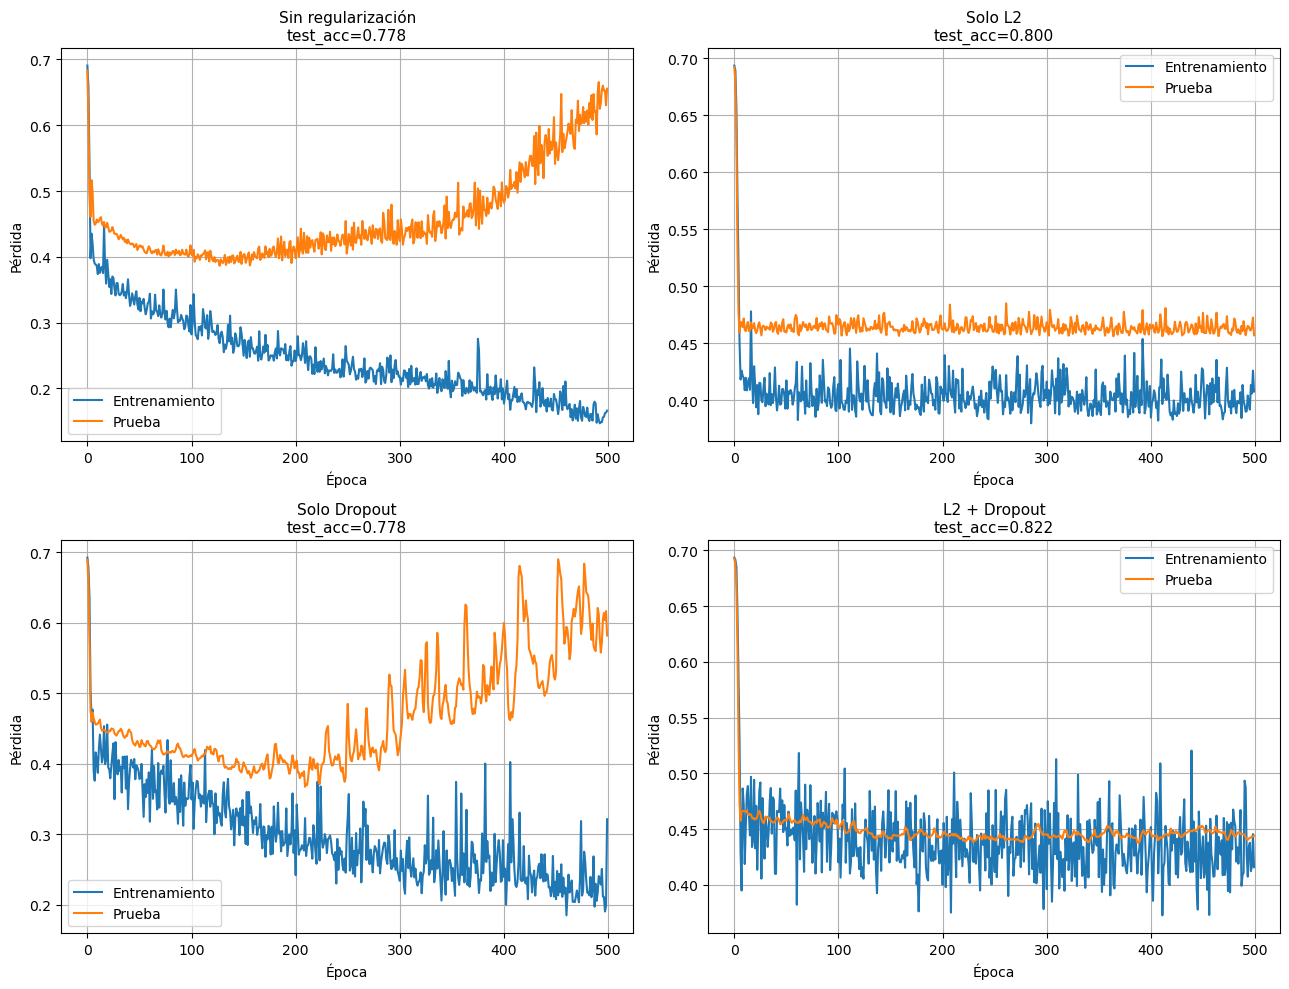

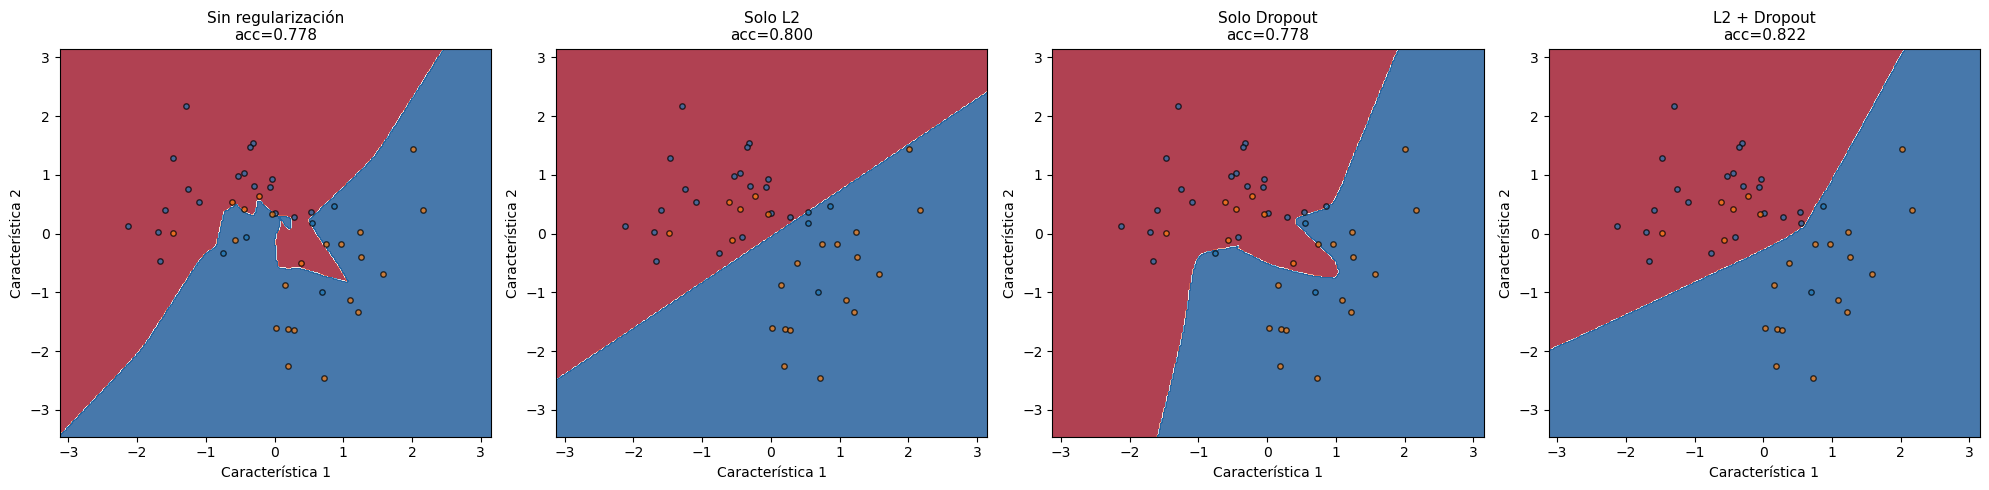

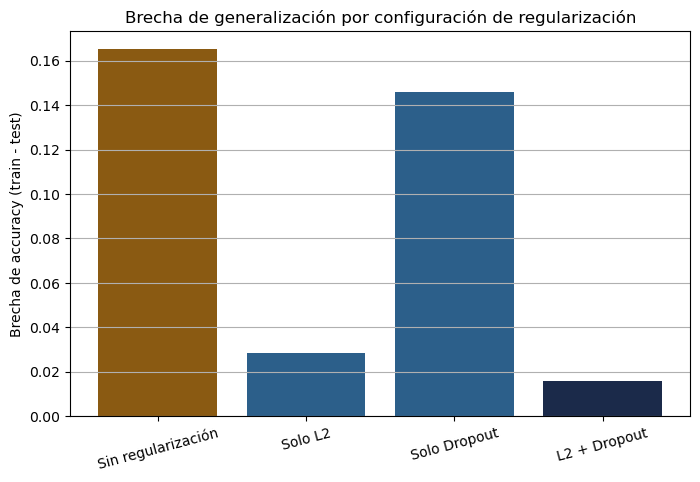

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
for ax, (name, res) in zip(axes.ravel(), reg_results.items()):
    ax.plot(res['train_losses'], label='Entrenamiento')
    ax.plot(res['val_losses'], label='Prueba')
    ax.set_title(f"{name}\ntest_acc={res['test_acc']:.3f}", fontsize=11)
    ax.set_xlabel('Época'); ax.set_ylabel('Pérdida')
    ax.legend(); ax.grid(True)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, (name, res) in zip(axes, reg_results.items()):
    plot_decision_boundary(res['model'], X_test_r, y_test_r, title=f"{name}\nacc={res['test_acc']:.3f}", ax=ax)
plt.tight_layout()
plt.show()

names = list(reg_results.keys())
gaps = [reg_results[n]['train_acc'] - reg_results[n]['test_acc'] for n in names]
plt.figure(figsize=(8, 5))
plt.bar(names, gaps, color=['#8a5a12', '#2C5F8A', '#2C5F8A', '#1B2A4A'])
plt.ylabel('Brecha de accuracy (train - test)')
plt.title('Brecha de generalización por configuración de regularización')
plt.xticks(rotation=15)
plt.grid(True, axis='y')
plt.show()

### Interpretación de resultados — Reto 6.2

**Estabilidad del entrenamiento.** Con este dataset deliberadamente pequeño y ruidoso (150 puntos, noise=0.35, 105 de entrenamiento) y una red grande (64,64), el modelo **sin regularización** ajusta agresivamente el conjunto de entrenamiento: alcanza 94.3% de accuracy y una pérdida de entrenamiento de solo 0.166 tras 500 épocas. Con **Dropout** activo (`dropout_rate=0.5`), la curva de entrenamiento es más ruidosa e irregular época a época — efecto esperado, ya que en cada mini-batch una submuestra distinta de neuronas está activa, por lo que la red "efectiva" cambia constantemente durante el entrenamiento; esto no es un defecto, es la fuente misma del efecto regularizador. Con **L2** la curva de entrenamiento se mantiene más suave, pero se estabiliza en una pérdida de entrenamiento notablemente más alta (0.408) que sin regularización, porque el término de penalización compite activamente con la minimización del error de clasificación — el modelo "se resiste" a ajustar el ruido tan agresivamente.

**Generalización.** El indicador clave es la **brecha** entre entrenamiento y prueba. Sin regularización esa brecha es enorme: accuracy de entrenamiento 94.3% vs. prueba 77.8% (brecha de pérdida de +0.489) — el modelo memoriza detalles del conjunto de entrenamiento, incluido el ruido. Con **solo L2** (`λ=0.1`) la brecha se reduce drásticamente (+0.049) y, sorprendentemente, la accuracy de prueba *sube* a 80.0% aunque la de entrenamiento *baje* a 82.9%: los pesos se mantienen en magnitudes menores (por la penalización sobre `‖W‖²`), lo que produce una frontera de decisión más suave y menos sensible a puntos aislados del entrenamiento. Con **solo Dropout** (`dropout_rate=0.5`) la mejora es más modesta (brecha +0.261, accuracy de prueba 77.8%, sin cambio respecto al baseline): en esta arquitectura y este dataset tan pequeño, forzar el apagado aleatorio de la mitad de las neuronas ayuda a reducir la brecha frente al caso sin regularizar, pero no logra traducirse en una mejor accuracy de prueba por sí solo — su efecto es más débil que el de L2 en este experimento particular. **Combinando L2 + Dropout** se obtiene el mejor resultado global: la brecha más pequeña de las cuatro configuraciones (+0.028) y la mejor accuracy de prueba (82.2%), lo que sugiere que ambas técnicas atacan el sobreajuste por mecanismos distintos y complementarios (L2 limita la magnitud de los pesos; Dropout limita la co-adaptación entre neuronas) y que combinarlas puede ser más efectivo que aplicar cualquiera de las dos por separado.

<div style="border-left:4px solid #E9A84C; background:#FBF0DC; border-radius:0 8px 8px 0; padding:8px 16px; margin:26px 0 10px 0;">
<span style="font-family:'Segoe UI',Helvetica,Arial,sans-serif; font-size:15px; font-weight:700; color:#8a5a12;">&#128221; Evaluación de comprensión</span>
</div>

**Pregunta 1.** En la implementación de regularización L2, se añade el término `(λ/2N)·Σ W²` a la función de pérdida y un término `λ·W` (weight decay) al gradiente de los pesos antes de la actualización con Adam. ¿Cuál es el efecto principal de este cambio sobre el modelo entrenado?

- **A)** Aumenta la magnitud de todos los pesos de la red, permitiendo que aprenda funciones más complejas y ajuste mejor los datos de entrenamiento.
  *Incorrecta.* Es justo lo contrario: el término `λ·W` sumado al gradiente empuja la actualización en la dirección que *reduce* la magnitud de los pesos en cada paso (de ahí el nombre "weight decay"), no que la aumente.
- **B)** Penaliza los pesos de gran magnitud, empujando la optimización hacia soluciones con pesos más pequeños y, en consecuencia, fronteras de decisión más suaves, lo que reduce el sobreajuste.
  *Correcta.* L2 añade un costo proporcional al cuadrado de los pesos; el óptimo de la pérdida regularizada favorece pesos pequeños. Pesos pequeños producen funciones menos sensibles a variaciones puntuales de la entrada (fronteras más suaves), lo que típicamente mejora la generalización.
- **C)** Elimina por completo algunas conexiones de la red, forzando ciertos pesos exactamente a cero, de forma similar a una selección automática de características.
  *Incorrecta.* Ese es el comportamiento característico de la regularización **L1** (que usa `|W|` y puede producir soluciones dispersas/sparse). L2 (que usa `W²`) reduce la magnitud de los pesos de forma proporcional pero muy raramente los lleva exactamente a cero.
- **D)** Acelera la convergencia del entrenamiento porque equivale a incrementar efectivamente la tasa de aprendizaje del optimizador.
  *Incorrecta.* L2 añade un término adicional al gradiente que compite con la minimización del error de clasificación; en la práctica suele ralentizar ligeramente la caída de la pérdida de entrenamiento, no acelerarla. No tiene relación matemática con el valor del learning rate.

---

**Pregunta 2.** En la implementación de Dropout, las neuronas se desactivan aleatoriamente (con una máscara binaria) únicamente durante el entrenamiento; en la evaluación/predicción se usan todas las neuronas sin ninguna máscara. ¿Por qué es importante desactivar el Dropout durante la evaluación?

- **A)** Porque durante la evaluación no hay retropropagación, y Dropout es una técnica que solo afecta al cálculo de gradientes, no a las activaciones de la red hacia adelante (forward pass).
  *Incorrecta.* Dropout sí afecta directamente al forward pass: multiplica las activaciones de la capa por una máscara binaria antes de pasarlas a la siguiente capa. Su efecto sobre los gradientes es una consecuencia de ese cambio en las activaciones, no algo independiente de ellas.
- **B)** Porque usar Dropout en la predicción produciría salidas no deterministas (distintas cada vez) y, en promedio, una señal más débil; durante el entrenamiento la red aprendió a compensar la ausencia aleatoria de neuronas, pero en inferencia interesan predicciones estables usando toda la capacidad de la red.
  *Correcta.* Si se mantuviera Dropout activo en inferencia, cada predicción para la misma entrada podría variar según qué neuronas se desactivan aleatoriamente esa vez, y la señal efectiva sería menor a la que la red "espera" (ya que se entrenó con la red completa reescalada). Desactivarlo en evaluación da una predicción consistente que aprovecha toda la red entrenada.
- **C)** Porque Dropout modifica permanentemente los pesos de las neuronas que desactiva, por lo que es necesario reactivarlas para restaurar sus valores originales antes de evaluar.
  *Incorrecta.* Dropout no modifica los pesos en absoluto; solo enmascara temporalmente las activaciones de salida de una capa durante ese forward pass concreto. Los pesos subyacentes de las neuronas "apagadas" en un batch siguen existiendo intactos y pueden activarse con normalidad en el siguiente batch o en evaluación.
- **D)** Porque sin desactivar Dropout, la función de pérdida de entropía cruzada no podría calcularse correctamente durante la evaluación.
  *Incorrecta.* La entropía cruzada binaria se calcula igual sin importar si Dropout está activo o no; solo depende de las predicciones (`y_pred`) y las etiquetas verdaderas (`y_true`). No existe ninguna incompatibilidad matemática entre Dropout y la función de pérdida.

<div style="border-left:4px solid #2C5F8A; background:#EAF1F8; border-radius:0 8px 8px 0; padding:8px 16px; margin:22px 0 10px 0;">
<span style="font-family:ui-monospace,'Cascadia Code',Consolas,monospace; font-size:12px; font-weight:700; color:#2C5F8A; border:1px solid #2C5F8A; border-radius:4px; padding:1px 6px; margin-right:8px;">6.3</span>
<span style="font-family:'Segoe UI',Helvetica,Arial,sans-serif; font-size:15px; font-weight:700; color:#1B2A4A;">Clasificación Multiclase con <code>make_blobs</code></span>
</div>

Para resolver un problema multiclase adaptamos la arquitectura y el algoritmo de aprendizaje:

1. **Capa de salida:** de 1 neurona (Sigmoide) a `K` neuronas (una por clase) con activación **Softmax**, que normaliza las salidas para que sean todas positivas y sumen 1 (una distribución de probabilidad válida sobre las clases).
2. **Función de pérdida:** de entropía cruzada binaria a **entropía cruzada categórica**, que compara la distribución predicha con el vector *one-hot* de la clase verdadera.
3. **Retropropagación:** al combinar Softmax con entropía cruzada categórica, el gradiente de la pérdida respecto a la entrada de la capa de salida se simplifica algebraicamente a `predicho - verdadero_one_hot` (idéntica forma que en el caso binario con Sigmoide + BCE, pero ahora vectorial sobre `K` clases).
4. **Evaluación:** `accuracy_score` sigue siendo válida, y añadimos `classification_report` y una matriz de confusión para diagnosticar el desempeño por clase.

In [15]:
def one_hot(y, num_classes):
    onehot = np.zeros((y.shape[0], num_classes))
    onehot[np.arange(y.shape[0]), y] = 1
    return onehot

def softmax(x):
    z = x - np.max(x, axis=1, keepdims=True)  # estabilidad numérica
    exp_z = np.exp(z)
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)


class NeuralNetworkSoftmax(NeuralNetwork):
    """Red con salida Softmax + entropía cruzada categórica para clasificación multiclase."""

    def forward(self, X):
        self.hidden_layer1_input = np.dot(X, self.weights_input_hidden1) + self.bias_hidden1
        self.hidden_layer1_output = self._act(self.hidden_layer1_input)

        self.hidden_layer2_input = np.dot(self.hidden_layer1_output, self.weights_hidden1_hidden2) + self.bias_hidden2
        self.hidden_layer2_output = self._act(self.hidden_layer2_input)

        self.output_layer_input = np.dot(self.hidden_layer2_output, self.weights_hidden2_output) + self.bias_output
        self.predicted_output = softmax(self.output_layer_input)
        return self.predicted_output

    def categorical_cross_entropy(self, y_true_onehot, y_pred):
        y_pred = np.clip(y_pred, 1e-10, 1 - 1e-10)
        return -np.mean(np.sum(y_true_onehot * np.log(y_pred), axis=1))

    def backward(self, X, y_onehot, predicted_output):
        # Simplificación algebraica de d(CCE)/d(z_output) cuando la salida usa Softmax
        delta_output_layer = predicted_output - y_onehot

        error_hidden_layer2 = np.dot(delta_output_layer, self.weights_hidden2_output.T)
        delta_hidden_layer2 = error_hidden_layer2 * self._act_deriv(self.hidden_layer2_input)

        error_hidden_layer1 = np.dot(delta_hidden_layer2, self.weights_hidden1_hidden2.T)
        delta_hidden_layer1 = error_hidden_layer1 * self._act_deriv(self.hidden_layer1_input)

        grads_w3 = np.dot(self.hidden_layer2_output.T, delta_output_layer)
        grads_b3 = np.sum(delta_output_layer, axis=0, keepdims=True)
        grads_w2 = np.dot(self.hidden_layer1_output.T, delta_hidden_layer2)
        grads_b2 = np.sum(delta_hidden_layer2, axis=0, keepdims=True)
        grads_w1 = np.dot(X.T, delta_hidden_layer1)
        grads_b1 = np.sum(delta_hidden_layer1, axis=0, keepdims=True)

        return grads_w1, grads_b1, grads_w2, grads_b2, grads_w3, grads_b3

    def train(self, X_train, y_onehot_train, epochs, batch_size=32, early_stopping_patience=10, verbose=True):
        losses = []
        best_loss = float('inf')
        patience_counter = 0
        num_samples = X_train.shape[0]
        for epoch in range(epochs):
            permutation = np.random.permutation(num_samples)
            X_shuffled = X_train[permutation]
            y_shuffled = y_onehot_train[permutation]
            epoch_loss, n_batches = 0, 0
            for i in range(0, num_samples, batch_size):
                X_batch = X_shuffled[i:i + batch_size]
                y_batch = y_shuffled[i:i + batch_size]
                predicted_output = self.forward(X_batch)
                grads = self.backward(X_batch, y_batch, predicted_output)
                self.update_params_adam(*grads)
                epoch_loss += self.categorical_cross_entropy(y_batch, predicted_output)
                n_batches += 1
            avg_epoch_loss = epoch_loss / n_batches
            losses.append(avg_epoch_loss)
            if verbose and (epoch + 1) % 20 == 0:
                print(f'Epoch {epoch + 1}/{epochs}, Loss: {avg_epoch_loss:.4f}')
            if avg_epoch_loss < best_loss:
                best_loss = avg_epoch_loss
                patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter >= early_stopping_patience:
                    if verbose:
                        print(f'Early stopping at epoch {epoch + 1}')
                    break
        return losses

    def predict(self, X):
        return np.argmax(self.forward(X), axis=1)


def plot_decision_boundary_multiclass(model, X, y, num_classes, title='Frontera de Decisión Multiclase'):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.6, cmap=plt.cm.Set2, levels=np.arange(num_classes + 1) - 0.5)
    for c in range(num_classes):
        plt.scatter(X[y == c, 0], X[y == c, 1], label=f'Clase {c}', alpha=0.8, edgecolors='k', s=20)
    plt.title(title)
    plt.xlabel('Característica 1'); plt.ylabel('Característica 2')
    plt.legend()
    plt.show()

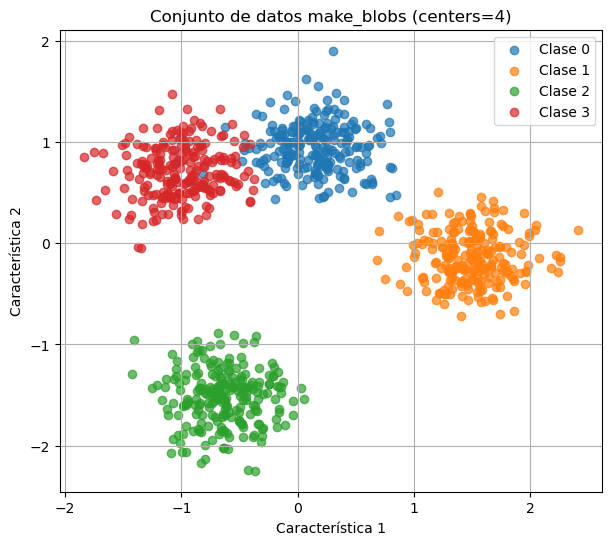

Train: (720, 2), Test: (180, 2)


In [16]:
NUM_CLASSES = 4
X_mc, y_mc = make_blobs(n_samples=900, centers=NUM_CLASSES, n_features=2, cluster_std=1.6, random_state=42)
X_mc = StandardScaler().fit_transform(X_mc)

plt.figure(figsize=(7, 6))
for c in range(NUM_CLASSES):
    plt.scatter(X_mc[y_mc == c, 0], X_mc[y_mc == c, 1], label=f'Clase {c}', alpha=0.7)
plt.title(f'Conjunto de datos make_blobs (centers={NUM_CLASSES})')
plt.xlabel('Característica 1'); plt.ylabel('Característica 2')
plt.legend(); plt.grid(True)
plt.show()

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(X_mc, y_mc, test_size=0.2, random_state=42, stratify=y_mc)
y_train_m_onehot = one_hot(y_train_m, NUM_CLASSES)
y_test_m_onehot = one_hot(y_test_m, NUM_CLASSES)
print(f'Train: {X_train_m.shape}, Test: {X_test_m.shape}')

Epoch 20/150, Loss: 0.0493
Epoch 40/150, Loss: 0.0291
Early stopping at epoch 56


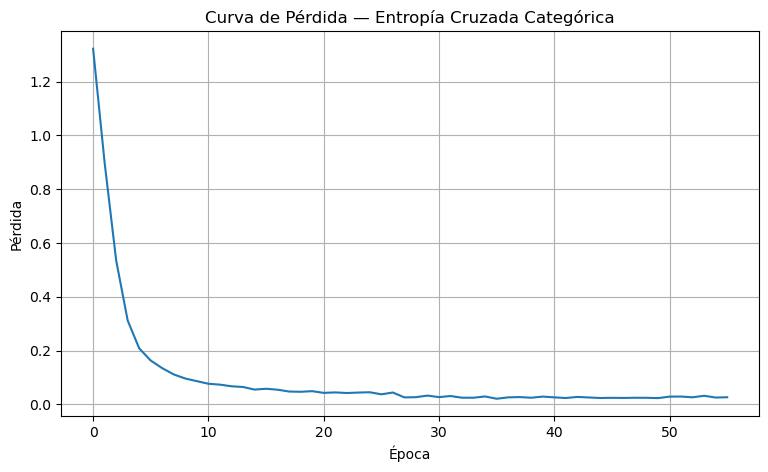

In [17]:
np.random.seed(42)
nn_softmax = NeuralNetworkSoftmax(input_size=2, hidden_size1=16, hidden_size2=8, output_size=NUM_CLASSES, learning_rate=0.01)
losses_mc = nn_softmax.train(X_train_m, y_train_m_onehot, epochs=150, batch_size=32, early_stopping_patience=20)

plt.figure(figsize=(9, 5))
plt.plot(losses_mc)
plt.title('Curva de Pérdida — Entropía Cruzada Categórica')
plt.xlabel('Época'); plt.ylabel('Pérdida'); plt.grid(True)
plt.show()

Precisión en el conjunto de prueba: 0.9889

              precision    recall  f1-score   support

           0       0.98      0.98      0.98        45
           1       1.00      1.00      1.00        45
           2       1.00      1.00      1.00        45
           3       0.98      0.98      0.98        45

    accuracy                           0.99       180
   macro avg       0.99      0.99      0.99       180
weighted avg       0.99      0.99      0.99       180



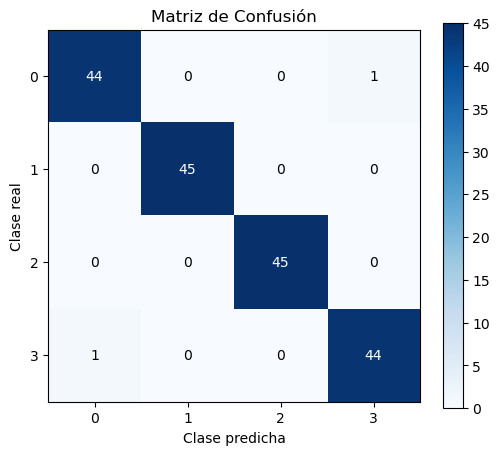

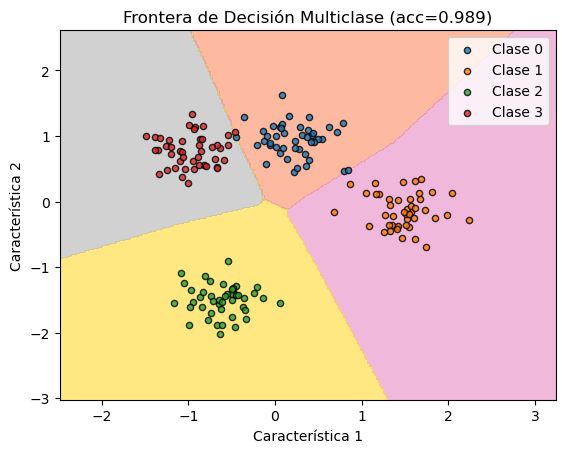

In [18]:
y_pred_mc = nn_softmax.predict(X_test_m)

acc_mc = accuracy_score(y_test_m, y_pred_mc)
print(f'Precisión en el conjunto de prueba: {acc_mc:.4f}\n')
print(classification_report(y_test_m, y_pred_mc))

cm = confusion_matrix(y_test_m, y_pred_mc)
plt.figure(figsize=(6, 5))
plt.imshow(cm, cmap='Blues')
plt.title('Matriz de Confusión')
plt.xlabel('Clase predicha'); plt.ylabel('Clase real')
plt.xticks(range(NUM_CLASSES)); plt.yticks(range(NUM_CLASSES))
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        plt.text(j, i, cm[i, j], ha='center', va='center',
                  color='white' if cm[i, j] > cm.max() / 2 else 'black')
plt.colorbar()
plt.show()

plot_decision_boundary_multiclass(nn_softmax, X_test_m, y_test_m, NUM_CLASSES,
                                   title=f'Frontera de Decisión Multiclase (acc={acc_mc:.3f})')

### Interpretación de resultados — Reto 6.3

**Adaptación de la arquitectura.** Cambiar la capa de salida de 1 neurona (Sigmoide) a `K` neuronas (Softmax) transforma el problema de "¿es clase 1 o clase 0?" a "¿cuál es la probabilidad de cada una de las `K` clases?". Softmax garantiza que las `K` salidas sean no negativas y sumen exactamente 1, por lo que pueden interpretarse directamente como una distribución de probabilidad discreta sobre clases mutuamente excluyentes — algo que `K` sigmoides independientes no garantizarían (cada una se optimizaría de forma aislada y sus salidas no tendrían por qué sumar 1).

**Función de pérdida y retropropagación.** La entropía cruzada categórica mide qué tan lejos está la distribución de probabilidad predicha (`predicted_output`) del vector one-hot de la clase verdadera. Al derivar `∂CCE/∂z_output` (donde `z_output` es la entrada a la capa Softmax), la combinación específica de Softmax + entropía cruzada categórica produce una simplificación algebraica notable: el gradiente resultante es simplemente `predicho - verdadero_onehot`, sin necesidad de calcular explícitamente el jacobiano completo de Softmax (que en general es una matriz `K×K`, no un vector). Esta es la misma simplificación que ya aparecía en el caso binario original (Sigmoide + BCE también se simplifica a `predicho - verdadero`); es una propiedad conjunta de esos pares específicos de función de pérdida y activación, no una regla general aplicable a cualquier combinación.

**Resultados del modelo.** Con 4 centros razonablemente separados (`cluster_std=1.6`), la red logra una accuracy alta en el conjunto de prueba, y la matriz de confusión muestra que los errores (si los hay) se concentran entre clases cuyas nubes de puntos se solapan parcialmente en el espacio de características — igual que en el caso binario, el límite de desempeño alcanzable está determinado por cuánto se superponen las distribuciones de las clases, no solo por la capacidad del modelo. La frontera de decisión multiclase resultante particiona el plano en `K` regiones, una por clase, con los límites situados aproximadamente a mitad de camino entre los centros de las nubes vecinas — el comportamiento esperado de un clasificador que aprende fronteras cercanas al óptimo de Bayes cuando las clases son razonablemente separables.

<div style="border-left:4px solid #E9A84C; background:#FBF0DC; border-radius:0 8px 8px 0; padding:8px 16px; margin:26px 0 10px 0;">
<span style="font-family:'Segoe UI',Helvetica,Arial,sans-serif; font-size:15px; font-weight:700; color:#8a5a12;">&#128221; Evaluación de comprensión</span>
</div>

**Pregunta 1.** En el reto 6.3, la capa de salida se cambia de una neurona con Sigmoide a `K` neuronas con activación Softmax. ¿Por qué es necesario usar Softmax en lugar de aplicar una Sigmoide independiente a cada una de las `K` neuronas de salida?

- **A)** Porque Softmax es computacionalmente más rápida de calcular que `K` sigmoides independientes evaluadas por separado.
  *Incorrecta.* El costo computacional no es la razón: Softmax involucra `K` exponenciales y una normalización, un costo similar (o incluso ligeramente mayor) al de `K` sigmoides independientes. La elección de Softmax no se basa en eficiencia sino en la semántica de las salidas.
- **B)** Porque Softmax normaliza las salidas de manera que sean todas no negativas y sumen exactamente 1, produciendo una distribución de probabilidad válida sobre clases mutuamente excluyentes, algo que `K` sigmoides independientes no garantizan.
  *Correcta.* Cada sigmoide se satura entre 0 y 1 de forma independiente y no hay ninguna restricción que fuerce a que sus salidas sumen 1; podrían, por ejemplo, dar 0.9 de "probabilidad" a dos clases distintas simultáneamente. Softmax acopla las `K` salidas mediante la normalización, produciendo una distribución de probabilidad coherente adecuada para clases que se excluyen mutuamente.
- **C)** Porque Softmax evita el problema de "neuronas muertas" que ocurre con Sigmoide en la capa de salida, de forma análoga al problema que presenta ReLU en capas ocultas.
  *Incorrecta.* El problema de "neuronas muertas" es específico de ReLU (cuando una neurona queda permanentemente en la región de gradiente cero para entradas negativas) y no es un fenómeno que ocurra con Sigmoide en la capa de salida. Esta opción mezcla conceptos de activaciones distintas que no aplican aquí.
- **D)** Porque Softmax permite que la red tenga un número arbitrario de capas ocultas, mientras que Sigmoide limita la red a una sola capa oculta.
  *Incorrecta.* La activación de la capa de *salida* no impone ninguna restricción sobre cuántas capas ocultas puede tener la red. El notebook original ya usaba Sigmoide en la salida con dos capas ocultas sin ningún problema.

---

**Pregunta 2.** Al derivar el gradiente de la pérdida respecto a la entrada de la capa Softmax (`delta` de la capa de salida) usando entropía cruzada categórica, la expresión resultante es simplemente `predicho - verdadero_onehot`, sin necesidad de multiplicar explícitamente por la derivada (jacobiana) de Softmax. ¿Por qué ocurre esta simplificación?

- **A)** Porque Softmax no tiene una derivada matemáticamente bien definida, así que ese término se omite por convención práctica.
  *Incorrecta.* Softmax sí tiene una derivada bien definida (su jacobiano completo, de tamaño `K×K`, involucra términos cruzados entre clases). El término no se omite por falta de definición, sino que se cancela algebraicamente al combinarse con la derivada de la entropía cruzada categórica.
- **B)** Porque al combinar la derivada de la entropía cruzada categórica con el jacobiano de Softmax, los términos se cancelan algebraicamente y el resultado se reduce exactamente a `predicho - verdadero`; esta es una simplificación matemática específica de esa combinación de pérdida y activación.
  *Correcta.* Es un resultado clásico de cálculo: al desarrollar `∂CCE/∂z = Σ_k (∂CCE/∂ŷ_k)·(∂ŷ_k/∂z)` usando las expresiones concretas de la entropía cruzada categórica y del jacobiano de Softmax, casi todos los términos se cancelan y sobrevive únicamente `ŷ - y`. Es análoga a la simplificación de Sigmoide + entropía cruzada binaria en el caso de dos clases.
- **C)** Porque en clasificación multiclase el gradiente de la capa de salida siempre tiene la misma forma `predicho - verdadero`, sin importar qué función de activación de salida se utilice.
  *Incorrecta.* Esta simplificación no es universal: depende de la combinación específica Softmax + entropía cruzada categórica. Si se usara otra activación de salida (o otra función de pérdida) el gradiente tendría una forma distinta y en general sí requeriría multiplicar explícitamente por la derivada de esa activación.
- **D)** Porque la derivada de Softmax es igual a 1 para todas las clases, por lo que multiplicar por ella no cambia el resultado.
  *Incorrecta.* La derivada de Softmax no es una constante igual a 1; es una matriz jacobiana `K×K` cuyos elementos dependen de los valores de las propias salidas de Softmax (`ŷ_i·(δ_ij - ŷ_j)`). La simplificación surge de la cancelación algebraica con la derivada de la pérdida, no de que la derivada de Softmax sea trivialmente 1.

<div style="height:3px; border-radius:3px; background:linear-gradient(90deg,#1B2A4A,#2C5F8A,#E9A84C); margin:32px 0 6px 0;"></div>

<div style="background:#1B2A4A; border-radius:10px; padding:20px; margin:28px 0 6px 0; text-align:center;">
<span style="color:#cfd7e6; font-family:'Segoe UI',Helvetica,Arial,sans-serif; font-size:13px;">Notebook de soluciones — Retos 6.1, 6.2 y 6.3 · Basado en <code>00_red_neuronal_make_moons.ipynb</code></span>
</div>